In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from utils import plot_metrics

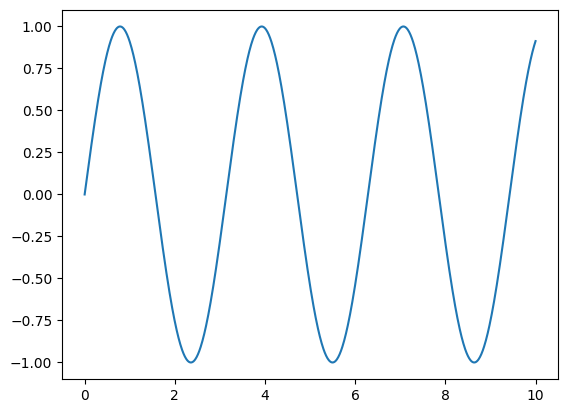

In [15]:
x = jnp.linspace(0, 10, 1000)
y = 2 * jnp.sin(x) * jnp.cos(x)

plt.plot(x, y);

In [16]:
x.devices()

{CpuDevice(id=0)}

In [17]:
from jax import jit
import numpy as np

def norm(X):
    X = X - X.mean(0)
    return X / X.std(0)

norm_compiled = jit(norm)
np.random.seed(1701)
X = jnp.array(np.random.rand(10000, 10))
np.allclose(norm(X), norm_compiled(X), atol=1E-6)

True

In [18]:
%timeit norm(X).block_until_ready()
%timeit norm_compiled(X).block_until_ready()

205 μs ± 10.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
174 μs ± 4.02 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [25]:
a = jnp.arange(3).reshape((3, -1))
b = jnp.arange(2).reshape((-1, 2))
a, b

(Array([[0],
        [1],
        [2]], dtype=int32),
 Array([[0, 1]], dtype=int32))

In [31]:
jnp.dot(jnp.arange(3), jnp.arange(3))


a = jnp.arange(5)
a, jnp.linalg.norm(a)

(Array([0, 1, 2, 3, 4], dtype=int32), Array(5.477226, dtype=float32))

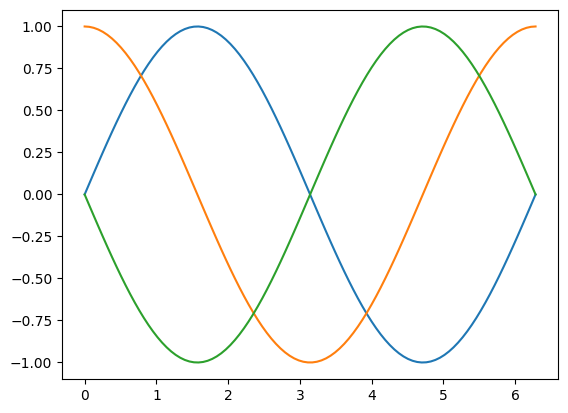

In [38]:
from jax import grad, vmap
def f(x):
    return jnp.sin(x)


a = jnp.linspace(0, 2 * jnp.pi, 100)

plt.plot(a, f(a))
plt.plot(a, vmap(grad(f))(a))
plt.plot(a, vmap(grad(grad(f)))(a))